# Customer Segmentation Analysis

**Objective:** Develop a customer segmentation solution by analyzing customer demographics, purchasing behavior, and transaction history to identify valuable customer groups for targeted marketing strategies.

**Pipeline:**
1. Data loading & cleaning
2. Exploratory data analysis
3. RFM (Recency, Frequency, Monetary) analysis
4. Customer segmentation (rule-based RFM scoring + K-Means clustering)
5. Data visualization
6. Business recommendations

**Dataset:** Synthetic e-commerce transaction data (1,200 customers, ~11,500 cleaned transactions across 8 product categories), generated to mirror the structure and messiness of real retail transaction logs (comparable in spirit to the UCI *Online Retail* dataset). Swap in a real transactions CSV with the same schema (`CustomerID`, `TransactionDate`, `TotalAmount`, `Category`, ...) to run this pipeline on live data.


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_cleaning import load_raw_data, clean_customers, clean_transactions, build_master_table
from rfm_analysis import compute_rfm, rfm_rule_based_segment
from segmentation import find_optimal_k, run_kmeans, label_clusters
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
%matplotlib inline


## 1. Data Loading & Cleaning

In [2]:
customers_raw, transactions_raw = load_raw_data()
print("Raw customers:", customers_raw.shape)
print("Raw transactions:", transactions_raw.shape)
customers_raw.head()


Raw customers: (1200, 5)
Raw transactions: (11528, 7)


,CustomerID,Age,Gender,City,SignupDate
0,C00001,40,Male,Hyderabad,2024-07-24
1,C00002,33,Female,Ahmedabad,2021-03-28
2,C00003,42,Other,Ahmedabad,2021-05-10
3,C00004,51,Female,Chennai,2021-08-16
4,C00005,32,Female,Bengaluru,2023-04-14


In [3]:
transactions_raw.head()


,TransactionID,CustomerID,TransactionDate,Category,Quantity,UnitPrice,TotalAmount
0,T000095,C00012,2024-07-02 21:02:17.453508,Apparel,5,984.29,4921.45
1,T004383,C00440,2024-04-21 20:04:17.459341,Toys,5,364.22,1821.12
2,T004880,C00489,2024-05-25 07:48:08.876979,Sports,5,491.04,2455.19
3,T005468,C00556,2024-07-07 20:04:53.325815,Apparel,2,1019.80,2039.61
4,T008229,C00861,2024-09-14 00:00:00.000000,Groceries,5,308.05,1540.26


### Data quality issues found
Before cleaning, we check for common data quality issues typical of real transaction logs:
- Invalid ages (e.g. negative values)
- Missing / inconsistent categorical fields (city, gender)
- Duplicate transaction records
- Missing or negative transaction amounts (data entry errors / unflagged returns)


In [4]:
print("Invalid ages:", (customers_raw['Age'] <= 0).sum())
print("Missing city:", customers_raw['City'].isna().sum())
print("Inconsistent gender labels:", customers_raw['Gender'].value_counts())
print()
print("Missing TotalAmount:", transactions_raw['TotalAmount'].isna().sum())
print("Negative/zero TotalAmount:", (transactions_raw['TotalAmount'] <= 0).sum())
print("Potential duplicate rows:", transactions_raw.duplicated(subset=['CustomerID','TransactionDate','Category','TotalAmount','Quantity']).sum())


Invalid ages: 10
Missing city: 10
Inconsistent gender labels: Gender
Male       563
Female     558
Other       74
unknown      5
Name: count, dtype: int64

Missing TotalAmount: 80
Negative/zero TotalAmount: 40
Potential duplicate rows: 60


In [5]:
customers_clean = clean_customers(customers_raw)
transactions_clean, cleaning_report = clean_transactions(transactions_raw)
master = build_master_table(customers_clean, transactions_clean)

print("Cleaning report:", cleaning_report)
print("Master table shape:", master.shape)
master.head()


Cleaning report: {'duplicates_removed': 60, 'nulls_removed': 80, 'negative_or_zero_removed': 40, 'final_row_count': 11348}
Master table shape: (11348, 11)


,TransactionID,CustomerID,TransactionDate,Category,Quantity,UnitPrice,TotalAmount,Age,Gender,City,SignupDate
0,T000095,C00012,2024-07-02 21:02:17.453508,Apparel,5,984.29,4921.45,35,Female,Jaipur,2023-07-16
1,T004383,C00440,2024-04-21 20:04:17.459341,Toys,5,364.22,1821.12,34,Female,Chennai,2023-04-30
2,T004880,C00489,2024-05-25 07:48:08.876979,Sports,5,491.04,2455.19,53,Male,Kolkata,2021-11-24
3,T005468,C00556,2024-07-07 20:04:53.325815,Apparel,2,1019.80,2039.61,30,Female,Delhi,2021-08-16
4,T008229,C00861,2024-09-14 00:00:00.000000,Groceries,5,308.05,1540.26,37,Other,Bengaluru,2024-09-13


## 2. Exploratory Data Analysis

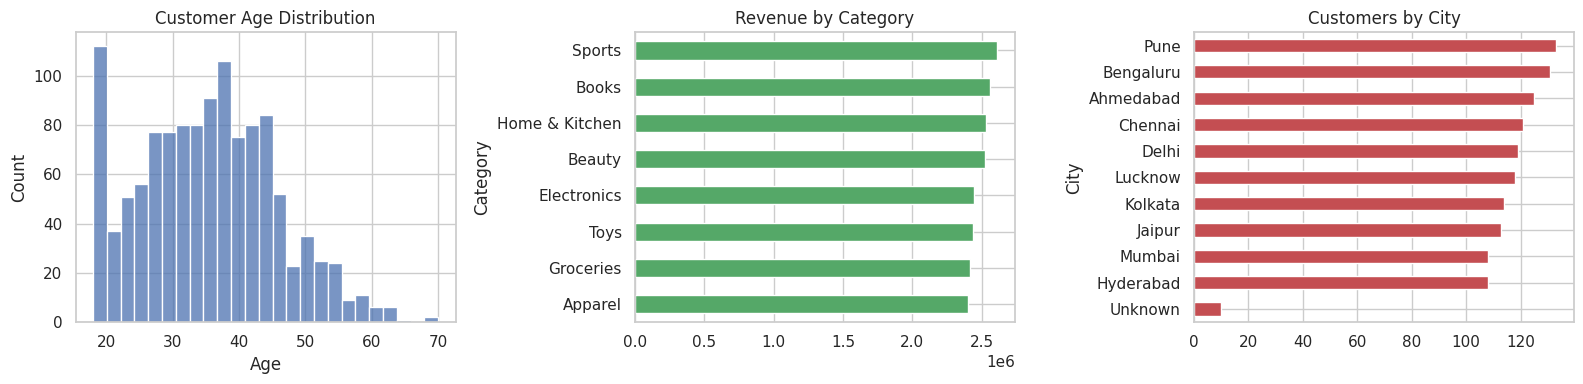

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(customers_clean['Age'], bins=25, ax=axes[0], color='#4C72B0')
axes[0].set_title('Customer Age Distribution')

master.groupby('Category')['TotalAmount'].sum().sort_values().plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].set_title('Revenue by Category')

master.groupby('City')['CustomerID'].nunique().sort_values().plot(kind='barh', ax=axes[2], color='#C44E52')
axes[2].set_title('Customers by City')
plt.tight_layout()
plt.show()


In [7]:
print(f"Total customers: {customers_clean['CustomerID'].nunique():,}")
print(f"Total transactions: {len(transactions_clean):,}")
print(f"Total revenue: {transactions_clean['TotalAmount'].sum():,.0f}")
print(f"Average order value: {transactions_clean['TotalAmount'].mean():,.2f}")
print(f"Date range: {transactions_clean['TransactionDate'].min().date()} to {transactions_clean['TransactionDate'].max().date()}")


Total customers: 1,200
Total transactions: 11,348
Total revenue: 19,919,415
Average order value: 1,755.32
Date range: 2023-03-28 to 2024-12-30


## 3. RFM Analysis

In [8]:
rfm = compute_rfm(transactions_clean)
rfm['Segment_RuleBased'] = rfm.apply(rfm_rule_based_segment, axis=1)
rfm.head()


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment_RuleBased
0,C00001,1,25,73849.75,5,5,5,555,15,Champions
1,C00002,71,4,4383.75,3,2,3,323,8,Needs Attention
2,C00003,9,9,13806.70,5,3,4,534,12,Loyal Customers
3,C00004,127,2,3370.41,2,1,2,212,5,Dormant / Lost
4,C00005,358,3,2573.20,1,1,2,112,4,Dormant / Lost


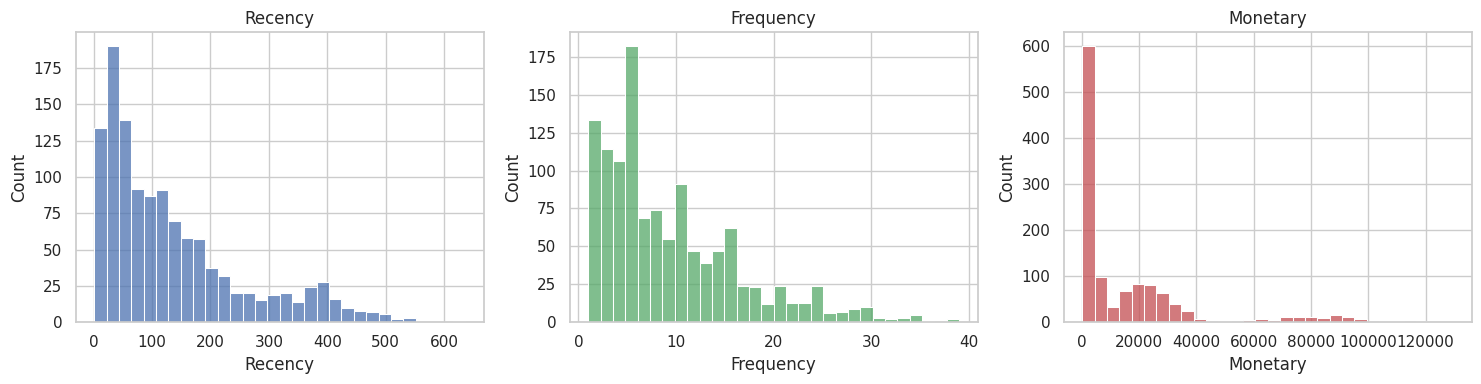

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(rfm['Recency'], bins=30, ax=axes[0], color='#4C72B0'); axes[0].set_title('Recency')
sns.histplot(rfm['Frequency'], bins=30, ax=axes[1], color='#55A868'); axes[1].set_title('Frequency')
sns.histplot(rfm['Monetary'], bins=30, ax=axes[2], color='#C44E52'); axes[2].set_title('Monetary')
plt.tight_layout()
plt.show()


### Rule-based RFM segments
Using standard RFM quintile scoring, customers are bucketed into business-readable segments (Champions, Loyal, At Risk, New, Dormant, Needs Attention) purely from R/F/M score thresholds.


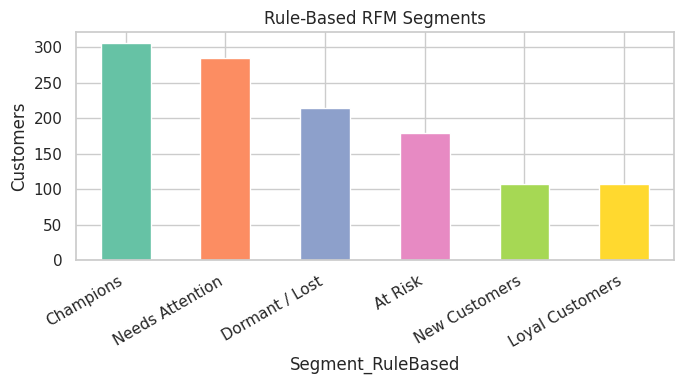

In [10]:
rfm['Segment_RuleBased'].value_counts().plot(kind='bar', figsize=(7,4), color=sns.color_palette('Set2'))
plt.title('Rule-Based RFM Segments')
plt.ylabel('Customers')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 4. Customer Segmentation via K-Means Clustering

Rule-based scoring is transparent but rigid. We complement it with **K-Means clustering** on standardized, log-transformed RFM features to let the data reveal natural groupings, and validate the choice of *k* using the elbow method and silhouette score.


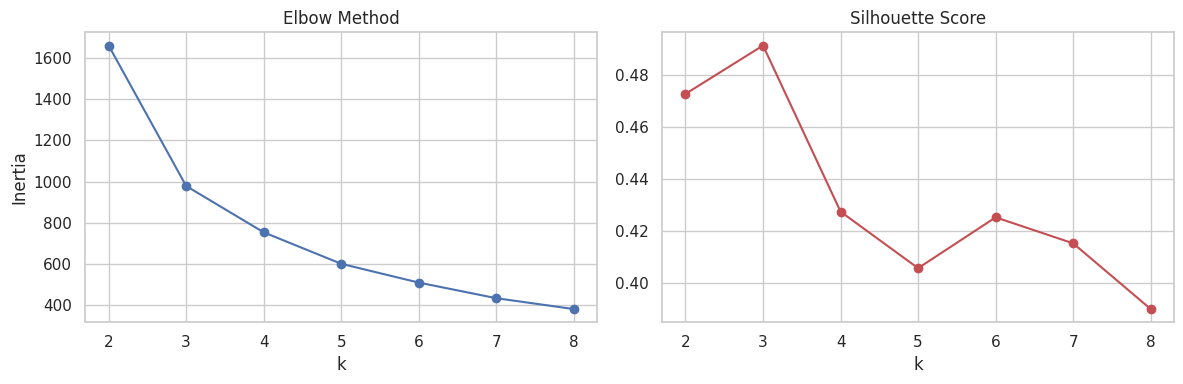

{2: 0.473, 3: 0.491, 4: 0.428, 5: 0.406, 6: 0.425, 7: 0.415, 8: 0.39}


In [11]:
features = rfm[['Recency','Frequency','Monetary']].copy()
features['Frequency'] = np.log1p(features['Frequency'])
features['Monetary'] = np.log1p(features['Monetary'])
X_scaled = StandardScaler().fit_transform(features)

ks, inertias, sil_scores = find_optimal_k(X_scaled, k_range=range(2,9))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(ks, inertias, marker='o'); axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(ks, sil_scores, marker='o', color='#C44E52'); axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k')
plt.tight_layout()
plt.show()

print(dict(zip(ks, [round(s,3) for s in sil_scores])))


In [12]:
# k=4 chosen for business interpretability (Champions / At Risk / Dormant / Price-Sensitive),
# even where silhouette score peaks at k=2, since 2 clusters is too coarse for targeted marketing.
K = 4
rfm_clustered, X_scaled, km_model = run_kmeans(rfm, k=K)
rfm_labeled, cluster_profile = label_clusters(rfm_clustered)

print(cluster_profile)
rfm_labeled['Segment_Cluster'].value_counts()


            Recency  Frequency      Monetary  value_rank  recency_rank
Cluster                                                               
0        140.836910  10.828326  16191.888841         2.0           3.0
1         94.100446   4.901786   2903.140982         3.0           2.0
2         30.854305  19.238411  47191.436457         1.0           1.0
3        352.921659   3.774194   2738.634977         4.0           4.0


Segment_Cluster
Price-Sensitive / Low-Value    448
Champions                      302
At Risk                        233
Dormant / Lost                 217
Name: count, dtype: int64

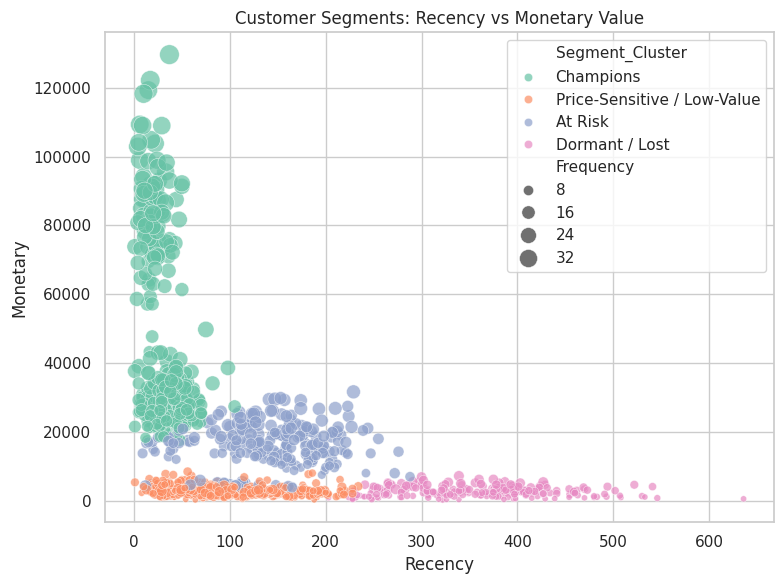

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm_labeled, x='Recency', y='Monetary', hue='Segment_Cluster',
                 size='Frequency', sizes=(20,200), alpha=0.7, palette='Set2')
plt.title('Customer Segments: Recency vs Monetary Value')
plt.tight_layout()
plt.show()


### Comparing rule-based vs cluster-based segmentation

In [14]:
pd.crosstab(rfm_labeled['Segment_RuleBased'], rfm_labeled['Segment_Cluster'])


Segment_Cluster,At Risk,Champions,Dormant / Lost,Price-Sensitive / Low-Value
Segment_RuleBased,,,,
At Risk,144,0,29,7
Champions,14,292,0,0
Dormant / Lost,0,0,148,66
Loyal Customers,72,10,0,25
Needs Attention,3,0,40,242
New Customers,0,0,0,108


The cross-tab shows strong agreement between the two approaches (e.g. rule-based *Champions* map almost entirely into cluster-based *Champions*), which validates both methods. The cluster-based segmentation is used going forward since it adapts thresholds to this dataset's actual distribution rather than fixed quintile cutoffs.


## 5. Segment Profiling & Business Recommendations

In [15]:
merged = master.merge(rfm_labeled[['CustomerID','Segment_Cluster']].drop_duplicates(), on='CustomerID', how='inner')

seg_summary = rfm_labeled.groupby('Segment_Cluster').agg(
    Customers=('CustomerID','count'),
    Avg_Recency=('Recency','mean'),
    Avg_Frequency=('Frequency','mean'),
    Avg_Monetary=('Monetary','mean'),
    Total_Revenue=('Monetary','sum'),
).round(1).sort_values('Total_Revenue', ascending=False)

seg_summary['Revenue_Share_%'] = (seg_summary['Total_Revenue'] / seg_summary['Total_Revenue'].sum() * 100).round(1)
seg_summary


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Share_%
Segment_Cluster,,,,,,
Champions,302,30.9,19.2,47191.4,14251813.8,71.5
At Risk,233,140.8,10.8,16191.9,3772710.1,18.9
Price-Sensitive / Low-Value,448,94.1,4.9,2903.1,1300607.2,6.5
Dormant / Lost,217,352.9,3.8,2738.6,594283.8,3.0


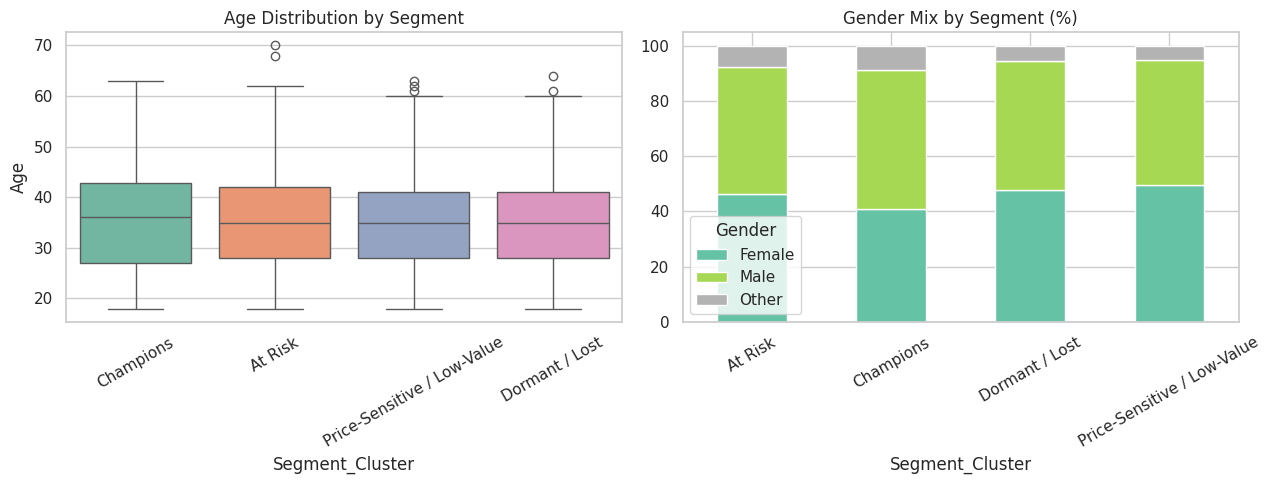

In [16]:
fig, axes = plt.subplots(1,2, figsize=(13,5))
sns.boxplot(data=merged.drop_duplicates('CustomerID'), x='Segment_Cluster', y='Age', ax=axes[0], hue='Segment_Cluster', palette='Set2', legend=False)
axes[0].set_title('Age Distribution by Segment')
axes[0].tick_params(axis='x', rotation=30)

gender_ct = pd.crosstab(merged.drop_duplicates('CustomerID')['Segment_Cluster'], merged.drop_duplicates('CustomerID')['Gender'], normalize='index')*100
gender_ct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Gender Mix by Segment (%)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


### Business Recommendations by Segment

**Champions** (recent, frequent, highest spend — largest share of revenue)
- Prioritize retention: early access to new products, loyalty tiers, personal outreach.
- Use as brand advocates — referral incentives, reviews, testimonials.
- Protect this segment from churn; it disproportionately drives revenue relative to its size.

**At Risk** (previously valuable, purchase recency slipping)
- Trigger win-back campaigns before they fully lapse — time-boxed discounts, "we miss you" emails.
- Investigate service or product issues that may have caused disengagement.

**Dormant / Lost** (long inactive, low historical value)
- Low-cost reactivation campaigns only (email, not high-touch outreach) given low expected ROI.
- Consider suppressing from expensive paid marketing channels.

**Price-Sensitive / Low-Value** (frequent, small-basket purchases)
- Bundle and upsell offers to increase basket size.
- Loyalty points tied to spend thresholds to nudge higher order values.

### Suggested next steps
1. Operationalize this pipeline with a live transactions feed (daily/weekly refresh).
2. A/B test segment-specific campaigns and measure lift vs a control group.
3. Feed `Segment_Cluster` into the CRM/marketing platform as a customer attribute for targeting.
4. Revisit segmentation quarterly — customer behavior and segment membership shift over time.


In [17]:
# Export final labeled customer table for downstream use (CRM, dashboard, etc.)
rfm_labeled.to_csv('../data/rfm_final_segments.csv', index=False)
seg_summary.to_csv('../outputs/segment_summary.csv')
print("Exported: data/rfm_final_segments.csv, outputs/segment_summary.csv")


Exported: data/rfm_final_segments.csv, outputs/segment_summary.csv
